<a href="https://colab.research.google.com/github/SharonAwuor/Machine-Learning/blob/main/Machine_learning(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir("/content/drive/MyDrive")

['AUD-20250206-WA0038.mp3',
 'ac.human',
 'Colab Notebooks',
 'Document from Dope Alfredo (1)',
 'Document from Dope Alfredo',
 'killerBee X Dope Alfredo - Drip (mastered).wav',
 'All.pdf',
 'original.pdf',
 'December styled.pdf',
 'December.pdf',
 'heal(6th of pain album).pdf',
 'pretty eyes.pdf',
 'rollercoaster.pdf',
 'rap as money.pdf',
 'not trying.pdf',
 'uko nami.pdf',
 'Untitled document (49).gdoc',
 'Mckayla\tTurpin.gdoc',
 'Wulutee\tCapuzzi (1).gdoc',
 'Edward\tRubio.gdoc',
 'Leslie\tMaurin.gdoc',
 'Selene\tMartinez.gdoc',
 'Sam\tPearson.gdoc',
 'Zachary\tHill.gdoc',
 'Alejandra\tPerez.gdoc',
 'James\tCole.gdoc',
 'Gloria\tRomero.gdoc',
 'Untitled document (48).gdoc',
 'Untitled document (47).gdoc',
 'Untitled document (46).gdoc',
 'AMBER\tSNYDER.gdoc',
 'Pdf .pdf',
 'invoice ya leo .pdf',
 'Samantha\tRodriguez.gdoc',
 'CHRISTOPHER\tTAYLOR.gdoc',
 'THOMAS\tOCHYLSKI.gdoc',
 'Untitled document (45).gdoc',
 'JACOB\tJOHNSON.gdoc',
 'AMANDA\tCUBBAGE.gdoc',
 'RACHEL\tSIEVERS.gdoc',

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cloud_performance_features.csv")

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

In [ ]:
print(df.shape)

df.head()

df.info()

(2000000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   cpu_usage                  float64
 1   memory_usage               float64
 2   network_traffic            float64
 3   power_consumption          float64
 4   num_executed_instructions  float64
 5   execution_time             float64
 6   energy_efficiency          float64
 7   task_type                  int64  
 8   task_priority              int64  
 9   task_status                int64  
 10  year                       float64
 11  month                      float64
 12  day                        float64
 13  hour                       float64
 14  day_of_week                float64
dtypes: float64(12), int64(3)
memory usage: 228.9 MB


In [ ]:
X = df.drop(columns=["execution_time"])

y = df["execution_time"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1600000, 14)
Testing samples: (400000, 14)


In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train, columns=X.columns)

print(X_train_df.isnull().sum())
print("Total NaNs:", X_train_df.isnull().sum().sum())

cpu_usage                         0
memory_usage                      0
network_traffic                   0
power_consumption                 0
num_executed_instructions         0
energy_efficiency                 0
task_type                         0
task_priority                     0
task_status                       0
year                         160441
month                        160441
day                          160441
hour                         160441
day_of_week                  160441
dtype: int64
Total NaNs: 802205


In [ ]:
# Check for missing values in every column
missing = df.isnull().sum()

print(missing[missing > 0])

year           200666
month          200666
day            200666
hour           200666
day_of_week    200666
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1003330


In [ ]:
df.isnull().sum()

,0
cpu_usage,0
memory_usage,0
network_traffic,0
power_consumption,0
num_executed_instructions,0
execution_time,0
energy_efficiency,0
task_type,0
task_priority,0
task_status,0


In [ ]:
print(df[["year", "month", "day", "hour", "day_of_week"]].dtypes)

year           float64
month          float64
day            float64
hour           float64
day_of_week    float64
dtype: object


In [ ]:
date_columns = ["year", "month", "day", "hour", "day_of_week"]

for col in date_columns:
    # Convert to numeric if needed
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fill NaN with the median
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

    # Convert to integer
    df[col] = df[col].astype(int)

In [ ]:
print(df[date_columns].isnull().sum())

print("Total missing values:", df.isnull().sum().sum())

year           0
month          0
day            0
hour           0
day_of_week    0
dtype: int64
Total missing values: 0


In [ ]:
X = df.drop(columns=["execution_time"])

y = df["execution_time"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1600000, 14)
Testing samples: (400000, 14)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = linear_model.predict(X_test_scaled)

In [ ]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MAPE     : {mape:.4f}")

Linear Regression Results
-------------------------
R² Score : -0.0000
RMSE     : 27.4157
MAE      : 22.5390
MAPE     : 6.0795


In [ ]:
cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² Scores:", cv_scores)
print("Average R²:", cv_scores.mean())

Cross-validation R² Scores: [-1.80327830e-05 -2.39490214e-05 -7.39297921e-06 -1.72642464e-05
  1.53708428e-06]
Average R²: -1.3020389143436617e-05


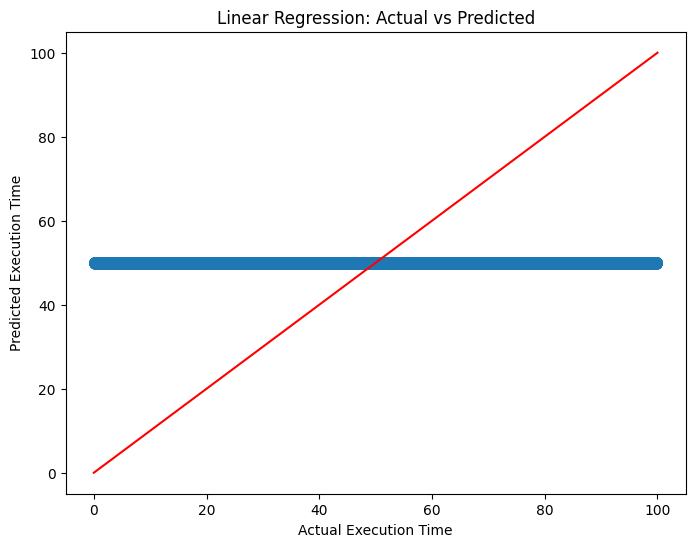

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Execution Time")
plt.ylabel("Predicted Execution Time")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation["execution_time"].sort_values(ascending=False))

execution_time               1.000000
energy_efficiency            0.001078
day                          0.000860
hour                         0.000468
network_traffic              0.000110
num_executed_instructions    0.000047
day_of_week                 -0.000090
task_status                 -0.000130
task_type                   -0.000273
cpu_usage                   -0.000361
task_priority               -0.000535
power_consumption           -0.000802
month                       -0.000893
memory_usage                -0.001046
year                              NaN
Name: execution_time, dtype: float64


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
ridge_predictions = ridge_model.predict(X_test_scaled)

In [ ]:
ridge_r2 = r2_score(y_test, ridge_predictions)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

ridge_mae = mean_absolute_error(y_test, ridge_predictions)

ridge_mape = mean_absolute_percentage_error(y_test, ridge_predictions)

print("Ridge Regression Results")
print("------------------------")
print(f"R² Score : {ridge_r2:.4f}")
print(f"RMSE     : {ridge_rmse:.4f}")
print(f"MAE      : {ridge_mae:.4f}")
print(f"MAPE     : {ridge_mape:.4f}")

Ridge Regression Results
------------------------
R² Score : -0.0000
RMSE     : 27.4157
MAE      : 22.5390
MAPE     : 6.0795


In [ ]:
ridge_cv = cross_val_score(
    Ridge(alpha=1.0),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² Scores:", ridge_cv)
print("Average R²:", ridge_cv.mean())

Cross-validation R² Scores: [-1.80327617e-05 -2.39490077e-05 -7.39296603e-06 -1.72642238e-05
  1.53708436e-06]
Average R²: -1.3020374979499927e-05


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "R²": [r2, ridge_r2],
    "RMSE": [rmse, ridge_rmse],
    "MAE": [mae, ridge_mae],
    "MAPE": [mape, ridge_mape]
})

comparison

,Model,R²,RMSE,MAE,MAPE
0,Linear Regression,-0.000015,27.415672,22.53905,6.079466
1,Ridge Regression,-0.000015,27.415672,22.53905,6.079466


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1, n_jobs=-1, random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_r2 = r2_score(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)

print("Random Forest Regression Results")
print("--------------------------------")
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"MAPE     : {rf_mape:.4f}")

Random Forest Regression Results
--------------------------------
R² Score : -1.0515
RMSE     : 39.2671
MAE      : 31.9615
MAPE     : 7.1714


In [ ]:
# Take a random sample of 100,000 rows
df_sample = df.sample(n=100000, random_state=42)

print(df_sample.shape)

(100000, 15)


In [ ]:
X = df_sample.drop(columns=["execution_time"])
y = df_sample["execution_time"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
rf_cv = cross_val_score(
    RandomForestRegressor(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² Scores:", rf_cv)
print("Average R²:", rf_cv.mean())

Cross-validation R² Scores: [-0.11470924 -0.10602196 -0.10888601 -0.11068419 -0.1110004 ]
Average R²: -0.11026036155036034


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest Regression"
    ],
    "R²": [
        r2,
        ridge_r2,
        rf_r2
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        rf_rmse
    ],
    "MAE": [
        mae,
        ridge_mae,
        rf_mae
    ],
    "MAPE": [
        mape,
        ridge_mape,
        rf_mape
    ]
})

comparison

,Model,R²,RMSE,MAE,MAPE
0,Linear Regression,-0.000015,27.415672,22.539050,6.079466
1,Ridge Regression,-0.000015,27.415672,22.539050,6.079466
2,Random Forest Regression,-1.051475,39.267084,31.961475,7.171389


In [ ]:
print(df["task_status"].value_counts())

task_status
2    800664
1    600217
0    599119
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["task_status"])

y = df["task_status"]

In [ ]:
print(df["task_status"].unique())

[2 0 1]


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["task_status"] = encoder.fit_transform(df["task_status"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.4003
Precision: 0.1603
Recall   : 0.4003
F1 Score : 0.2289


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00    119824
           1       0.00      0.00      0.00    120043
           2       0.40      1.00      0.57    160133

    accuracy                           0.40    400000
   macro avg       0.13      0.33      0.19    400000
weighted avg       0.16      0.40      0.23    400000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


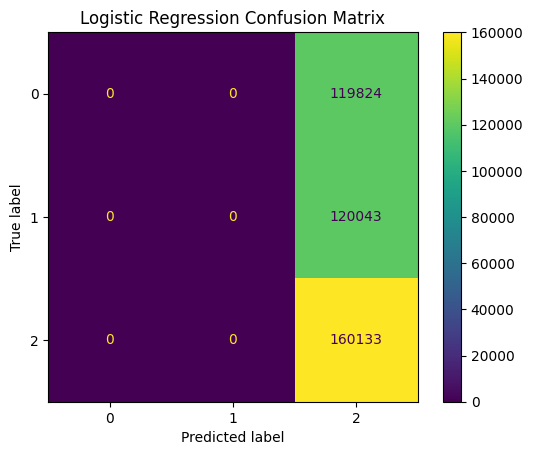

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
df["task_status"].value_counts()

,count
task_status,
2,800664
1,600217
0,599119


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation Accuracy:", cv_scores)
print("Average Accuracy:", cv_scores.mean())

Cross-validation Accuracy: [0.40033125 0.40033125 0.40033125 0.40033125 0.40033438]
Average Accuracy: 0.400331875


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["task_type"] = encoder.fit_transform(df["task_type"])
df["task_priority"] = encoder.fit_transform(df["task_priority"])

In [ ]:
import numpy as np

print("Predicted classes:")
print(np.unique(y_pred, return_counts=True))

Predicted classes:
(array([2]), array([400000]))


In [ ]:
print(X.dtypes)

cpu_usage                    float64
memory_usage                 float64
network_traffic              float64
power_consumption            float64
num_executed_instructions    float64
execution_time               float64
energy_efficiency            float64
task_type                      int64
task_priority                  int64
year                           int64
month                          int64
day                            int64
hour                           int64
day_of_week                    int64
dtype: object


In [ ]:
print(X.head())

   cpu_usage  memory_usage  network_traffic  power_consumption  \
0  54.881350     78.950861       164.775973         287.808986   
1  71.518937     29.901883       500.007595         362.273569   
2  50.054758     92.709195       203.674847         231.467903   
3  54.488318     88.100960       500.007595         195.639954   
4  42.365480     49.976089       500.007595         359.451537   

   num_executed_instructions  execution_time  energy_efficiency  task_type  \
0                     7527.0       69.345575           0.553589          2   
1                     5348.0       41.396040           0.349856          1   
2                     5483.0       24.602549           0.796277          1   
3                     5876.0       16.456670           0.529511          0   
4                     3361.0       55.307992           0.351907          1   

   task_priority  year  month  day  hour  day_of_week  
0              2  2023      1   25     9            2  
1              0  2023

In [ ]:
print(df[["task_type", "task_priority"]].head())

   task_type  task_priority
0          2              2
1          1              0
2          1              2
3          0              0
4          1              2


In [ ]:
print("Training Accuracy:", logistic_model.score(X_train_scaled, y_train))
print("Testing Accuracy :", logistic_model.score(X_test_scaled, y_test))

Training Accuracy: 0.400331875
Testing Accuracy : 0.4003325


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.3300
Precision: 0.3416
Recall   : 0.3300
F1 Score : 0.3303


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.30      0.35      0.32    119824
           1       0.30      0.37      0.33    120043
           2       0.40      0.29      0.33    160133

    accuracy                           0.33    400000
   macro avg       0.33      0.33      0.33    400000
weighted avg       0.34      0.33      0.33    400000



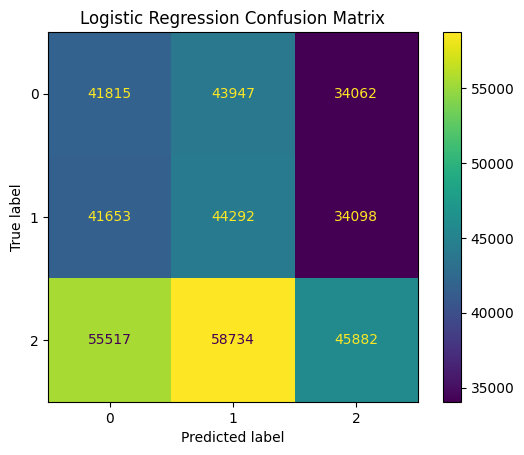

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [ ]:
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
knn_predictions = knn_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, knn_predictions)

precision = precision_score(
    y_test,
    knn_predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    knn_predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted"
)

print("KNN Classification Results")
print("--------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

KNN Classification Results
--------------------------
Accuracy : 0.3313
Precision: 0.3395
Recall   : 0.3313
F1 Score : 0.3318


In [ ]:
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       0.30      0.39      0.34    119824
           1       0.30      0.29      0.30    120043
           2       0.40      0.32      0.35    160133

    accuracy                           0.33    400000
   macro avg       0.33      0.33      0.33    400000
weighted avg       0.34      0.33      0.33    400000



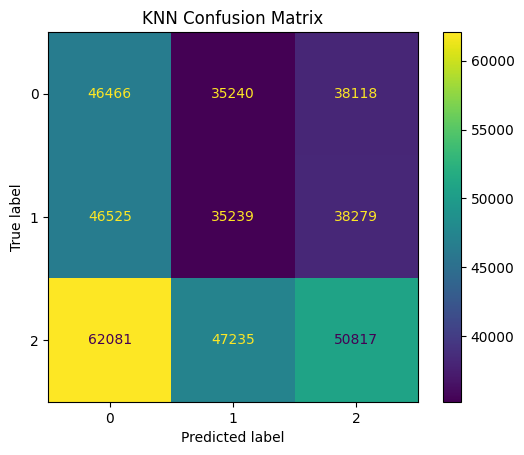

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions
)

plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation Accuracy:", cv_scores)
print("Average Accuracy:", cv_scores.mean())

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN Classifier"
    ],
    "Accuracy": [
        accuracy,
        accuracy
    ],
    "Precision": [
      precision ,
        precision
    ],
    "Recall": [
        recall,
        recall
    ],
    "F1 Score": [
        f1,
        f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.331305,0.339518,0.331305,0.331827
1,KNN Classifier,0.331305,0.339518,0.331305,0.331827
